# Reference Map Inference

Load a trained segmentation model and run inference on every Nth image from the REFERENCE MAP directory. Saves aerial images and prediction masks, plus diagnostic statistics.

**Instructions:**
1. Configure the settings below (RUN_NAME, CHECKPOINT, SAMPLE_INTERVAL)
2. Run all cells to process images and see diagnostics
3. Output saved to `REFERENCE_MAP_SONDERBORG/` folder:
   - `aerial/` - Original aerial images
   - `prediction/` - Predicted segmentation masks (RGB)
   - Statistics and visualizations in root folder

In [1]:
# Imports
import os
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import json
from collections import Counter
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# ========================================
# CONFIGURATION: Edit these variables
# ========================================

# Model configuration
RUN_NAME = "20260317_152458_pipelineA"  # <-- Your trained model run folder
CHECKPOINT = "best.pth"       # <-- Options: "best.pth", "latest.pth", "epoch_0010.pth"

# Dataset configuration
REFERENCE_MAP_DIR = Path(r"C:\Users\emilj\Documents\Thesis\TRAINING\ReferenceMapVejle_20260321_162024\aerial")
SAMPLE_INTERVAL = 1  # <-- Process every Nth image (26,367 total / 15 = ~1,758 images)

# Legend file from training dataset
LEGEND_FILE = Path(r"C:\Users\emilj\Documents\Thesis\TRAINING\aerial_Vejle\legend.txt")

# Output directory
OUTPUT_DIR = Path("REFERENCE_MAP_VEJLE_20260321_162024")
OUTPUT_AERIAL_DIR = OUTPUT_DIR / "aerial"
OUTPUT_PREDICTION_DIR = OUTPUT_DIR / "prediction"

OUTPUT_DIR.mkdir(exist_ok=True)
OUTPUT_AERIAL_DIR.mkdir(exist_ok=True, parents=True)
OUTPUT_PREDICTION_DIR.mkdir(exist_ok=True, parents=True)

# Paths (automatically constructed)
RUN_DIR = Path("runs") / RUN_NAME
CHECKPOINT_PATH = RUN_DIR / CHECKPOINT
CONFIG_PATH = RUN_DIR / "config.json"

# Validation
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Config not found: {CONFIG_PATH}")
if not LEGEND_FILE.exists():
    raise FileNotFoundError(f"Legend file not found: {LEGEND_FILE}")
if not REFERENCE_MAP_DIR.exists():
    raise FileNotFoundError(f"Reference map directory not found: {REFERENCE_MAP_DIR}")

print("="*70)
print("REFERENCE MAP INFERENCE")
print("="*70)
print(f"✓ Model: {RUN_NAME} / {CHECKPOINT}")
print(f"✓ Input: {REFERENCE_MAP_DIR}")
print(f"✓ Sampling: Every {SAMPLE_INTERVAL}th image")
print(f"✓ Output directory:   {OUTPUT_DIR}")
print(f"✓ Output aerial:      {OUTPUT_AERIAL_DIR}")
print(f"✓ Output prediction:  {OUTPUT_PREDICTION_DIR}")
print("="*70)

REFERENCE MAP INFERENCE
✓ Model: 20260317_152458_pipelineA / best.pth
✓ Input: C:\Users\emilj\Documents\Thesis\TRAINING\ReferenceMapVejle_20260321_162024\aerial
✓ Sampling: Every 1th image
✓ Output directory:   REFERENCE_MAP_VEJLE_20260321_162024
✓ Output aerial:      REFERENCE_MAP_VEJLE_20260321_162024\aerial
✓ Output prediction:  REFERENCE_MAP_VEJLE_20260321_162024\prediction


In [3]:
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
Memory: 8.5 GB


In [4]:
# Load configuration
with open(CONFIG_PATH, 'r') as f:
    config = json.load(f)

print("Model Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Model Configuration:
  run_name: 20260317_152458_pipelineA
  device: cuda
  seed: 42
  batch_size: 8
  accum_steps: 1
  num_workers: 0
  val_every: 1
  snapshot_every: 10
  early_stop: True
  patience: 15
  min_delta: 0.0001


In [5]:
# Parse legend and setup class mapping
CLASS_NAMES = []
COLOR_MAP = {}

with open(LEGEND_FILE, 'r') as f:
    for idx, line in enumerate(f):
        line = line.strip()
        if not line:
            continue
        name, rgb_part = line.split(' - rgb(')
        rgb_str = rgb_part.rstrip(' )')
        r, g, b = map(int, [x.strip() for x in rgb_str.split(',')])
        CLASS_NAMES.append(name.strip())
        COLOR_MAP[idx] = (r, g, b)

NUM_CLASSES = len(CLASS_NAMES)

print(f"Loaded {NUM_CLASSES} classes:")
for idx, name in enumerate(CLASS_NAMES):
    rgb = COLOR_MAP[idx]
    print(f"  {idx}: {name:<16} RGB{rgb}")

Loaded 6 classes:
  0: waterbodies      RGB(4, 4, 255)
  1: forest_trees     RGB(0, 167, 2)
  2: land             RGB(243, 255, 150)
  3: railway          RGB(193, 105, 53)
  4: roads            RGB(255, 0, 231)
  5: buildings        RGB(150, 150, 150)


In [6]:
# Load model architecture
model = smp.UnetPlusPlus(
    encoder_name='efficientnet-b3',
    encoder_weights='imagenet',
    in_channels=3,
    classes=NUM_CLASSES,
    decoder_attention_type='scse'
).to(device)

print("Model architecture loaded")

Model architecture loaded


In [7]:
# Load checkpoint weights
print(f"Loading checkpoint: {CHECKPOINT_PATH}")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    epoch = checkpoint.get('epoch', 'unknown')
    best_iou = checkpoint.get('best_iou', 'unknown')
    print(f"✓ Loaded checkpoint from epoch {epoch}")
    print(f"  Best IoU recorded: {best_iou}")
else:
    model.load_state_dict(checkpoint)
    print("✓ Loaded legacy checkpoint (state_dict only)")

model.eval()
print("✓ Model ready for inference")

Loading checkpoint: runs\20260317_152458_pipelineA\best.pth
✓ Loaded checkpoint from epoch 24
  Best IoU recorded: 0.6678693351003823
✓ Model ready for inference


In [8]:
# Prepare transform (same as training validation)
transform = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

print("Transform ready")

Transform ready


In [9]:
# Helper function to decode prediction masks
def decode_segmap(mask, color_map):
    """Convert class mask to RGB image"""
    h, w = mask.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)
    for k, v in color_map.items():
        out[mask == k] = v
    return out

print("Helper function defined")

Helper function defined


In [10]:
# Find and sample images
print(f"Scanning {REFERENCE_MAP_DIR}...")
all_images = []

for root, _, files in os.walk(REFERENCE_MAP_DIR):
    for f in files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
            all_images.append(os.path.join(root, f))

all_images = sorted(all_images)
total_images = len(all_images)

# Sample every Nth image
sampled_images = all_images[::SAMPLE_INTERVAL]
num_sampled = len(sampled_images)

print(f"\n{'='*70}")
print(f"IMAGE SAMPLING")
print(f"{'='*70}")
print(f"Total images found:    {total_images:>10,}")
print(f"Sample interval:       {SAMPLE_INTERVAL:>10}")
print(f"Images to process:     {num_sampled:>10,}")
print(f"Reduction:             {100 * (1 - num_sampled/total_images):>9.1f}%")
print(f"{'='*70}")

if num_sampled == 0:
    raise ValueError("No images found to process!")

Scanning C:\Users\emilj\Documents\Thesis\TRAINING\ReferenceMapVejle_20260321_162024\aerial...

IMAGE SAMPLING
Total images found:         4,400
Sample interval:                1
Images to process:          4,400
Reduction:                   0.0%


In [11]:
# Run inference on sampled images
print(f"\nRunning inference on {num_sampled:,} images...")

# Statistics tracking
class_pixel_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
processed_images = []
predictions = []

with torch.no_grad():
    for img_path in tqdm(sampled_images, desc="Processing"):
        try:
            # Load image
            img = np.array(Image.open(img_path).convert('RGB'))
            original_size = img.shape[:2]
            
            # Calculate relative path to preserve TMS structure (zoom/x/y.png)
            img_path_obj = Path(img_path)
            relative_path = img_path_obj.relative_to(REFERENCE_MAP_DIR)
            
            # Save aerial image (preserving directory structure)
            aerial_output_path = OUTPUT_AERIAL_DIR / relative_path
            aerial_output_path.parent.mkdir(parents=True, exist_ok=True)
            Image.fromarray(img).save(aerial_output_path)
            
            # Transform
            transformed = transform(image=img)
            img_tensor = transformed['image'].unsqueeze(0).to(device)
            
            # Predict
            output = model(img_tensor)
            pred = torch.argmax(output, dim=1).cpu().numpy()[0]
            
            # Save prediction as RGB image (preserving directory structure)
            pred_rgb = decode_segmap(pred, COLOR_MAP)
            prediction_output_path = OUTPUT_PREDICTION_DIR / relative_path
            prediction_output_path.parent.mkdir(parents=True, exist_ok=True)
            Image.fromarray(pred_rgb).save(prediction_output_path)
            
            # Collect statistics
            for c in range(NUM_CLASSES):
                class_pixel_counts[c] += (pred == c).sum()
            
            processed_images.append(img_path)
            predictions.append(pred)
            
        except Exception as e:
            print(f"\nError processing {img_path}: {e}")
            continue

print(f"\n✓ Successfully processed {len(processed_images):,} images")
print(f"✓ Saved {len(processed_images):,} aerial images to: {OUTPUT_AERIAL_DIR}")
print(f"✓ Saved {len(processed_images):,} prediction masks to: {OUTPUT_PREDICTION_DIR}")


Running inference on 4,400 images...


Processing:  94%|█████████▍| 4141/4400 [37:01<02:18,  1.86it/s]  


KeyboardInterrupt: 

In [12]:
# Calculate statistics
total_pixels = class_pixel_counts.sum()

print("\n" + "="*70)
print("INFERENCE DIAGNOSTICS")
print("="*70)

print(f"\nTotal pixels analyzed:    {total_pixels:>15,}")
print(f"Images processed:         {len(processed_images):>15,}")
print(f"Avg pixels per image:     {total_pixels / len(processed_images):>15,.0f}")

print(f"\n{'Class':<16} | {'Pixels':>15} | {'Percentage':>10} | {'Avg per Image':>15}")
print("-" * 70)
for i in range(NUM_CLASSES):
    pct = 100 * class_pixel_counts[i] / total_pixels
    avg_per_img = class_pixel_counts[i] / len(processed_images)
    print(f"{CLASS_NAMES[i]:<16} | {class_pixel_counts[i]:>15,} | {pct:>9.2f}% | {avg_per_img:>15,.0f}")


INFERENCE DIAGNOSTICS

Total pixels analyzed:      2,224,291,840
Images processed:                   4,141
Avg pixels per image:             537,139

Class            |          Pixels | Percentage |   Avg per Image
----------------------------------------------------------------------
waterbodies      |     109,903,268 |      4.94% |          26,540
forest_trees     |     357,550,664 |     16.07% |          86,344
land             |   1,620,330,773 |     72.85% |         391,290
railway          |       1,784,761 |      0.08% |             431
roads            |      74,845,703 |      3.36% |          18,074
buildings        |      59,876,671 |      2.69% |          14,459


In [13]:
# Identify potential issues
print("\n" + "="*70)
print("⚠️  POTENTIAL ISSUES")
print("="*70)

issues_found = False

# Check for dominant classes (>80%)
dominant_threshold = 80.0
for i in range(NUM_CLASSES):
    pct = 100 * class_pixel_counts[i] / total_pixels
    if pct > dominant_threshold:
        print(f"⚠️  {CLASS_NAMES[i]} dominates predictions ({pct:.1f}%)")
        print(f"   → May indicate over-prediction or actual data distribution")
        issues_found = True

# Check for rare classes (<1%)
rare_threshold = 1.0
for i in range(NUM_CLASSES):
    pct = 100 * class_pixel_counts[i] / total_pixels
    if pct < rare_threshold:
        print(f"⚠️  {CLASS_NAMES[i]} is rare in predictions ({pct:.3f}%)")
        print(f"   → May indicate under-detection or truly rare in reference map")
        issues_found = True

# Railway and Roads specific checks
railway_idx = 3
roads_idx = 4

railway_pct = 100 * class_pixel_counts[railway_idx] / total_pixels
roads_pct = 100 * class_pixel_counts[roads_idx] / total_pixels

print(f"\n📊 Key Classes Analysis:")
print(f"   Railway: {railway_pct:>6.3f}% ({class_pixel_counts[railway_idx]:>10,} pixels)")
print(f"   Roads:   {roads_pct:>6.3f}% ({class_pixel_counts[roads_idx]:>10,} pixels)")

if roads_pct < railway_pct:
    print(f"\n⚠️  Roads detected LESS than railway")
    print(f"   → This is unusual - roads typically have 10× more coverage")
    print(f"   → Model may be under-predicting roads (known issue from training)")
    issues_found = True

if not issues_found:
    print("\n✓ No obvious issues detected")


⚠️  POTENTIAL ISSUES
⚠️  railway is rare in predictions (0.080%)
   → May indicate under-detection or truly rare in reference map

📊 Key Classes Analysis:
   Railway:  0.080% ( 1,784,761 pixels)
   Roads:    3.365% (74,845,703 pixels)


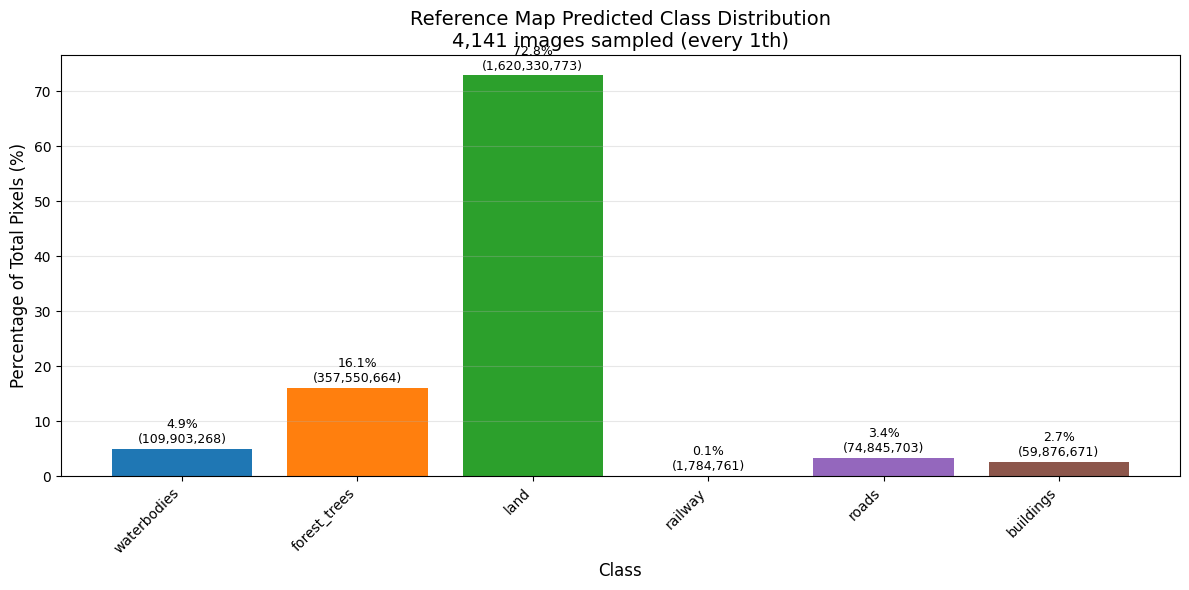

✓ Saved: REFERENCE_MAP_VEJLE_20260321_162024\class_distribution.png


In [14]:
# Visualization 1: Class distribution bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(NUM_CLASSES)
percentages = 100 * class_pixel_counts / total_pixels
bars = ax.bar(x, percentages, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'][:NUM_CLASSES])

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Percentage of Total Pixels (%)', fontsize=12)
ax.set_title(f'Reference Map Predicted Class Distribution\n{len(processed_images):,} images sampled (every {SAMPLE_INTERVAL}th)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, pct, count in zip(bars, percentages, class_pixel_counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{pct:.1f}%\n({count:,})', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUT_DIR / 'class_distribution.png'}")

Generating sample predictions visualization...


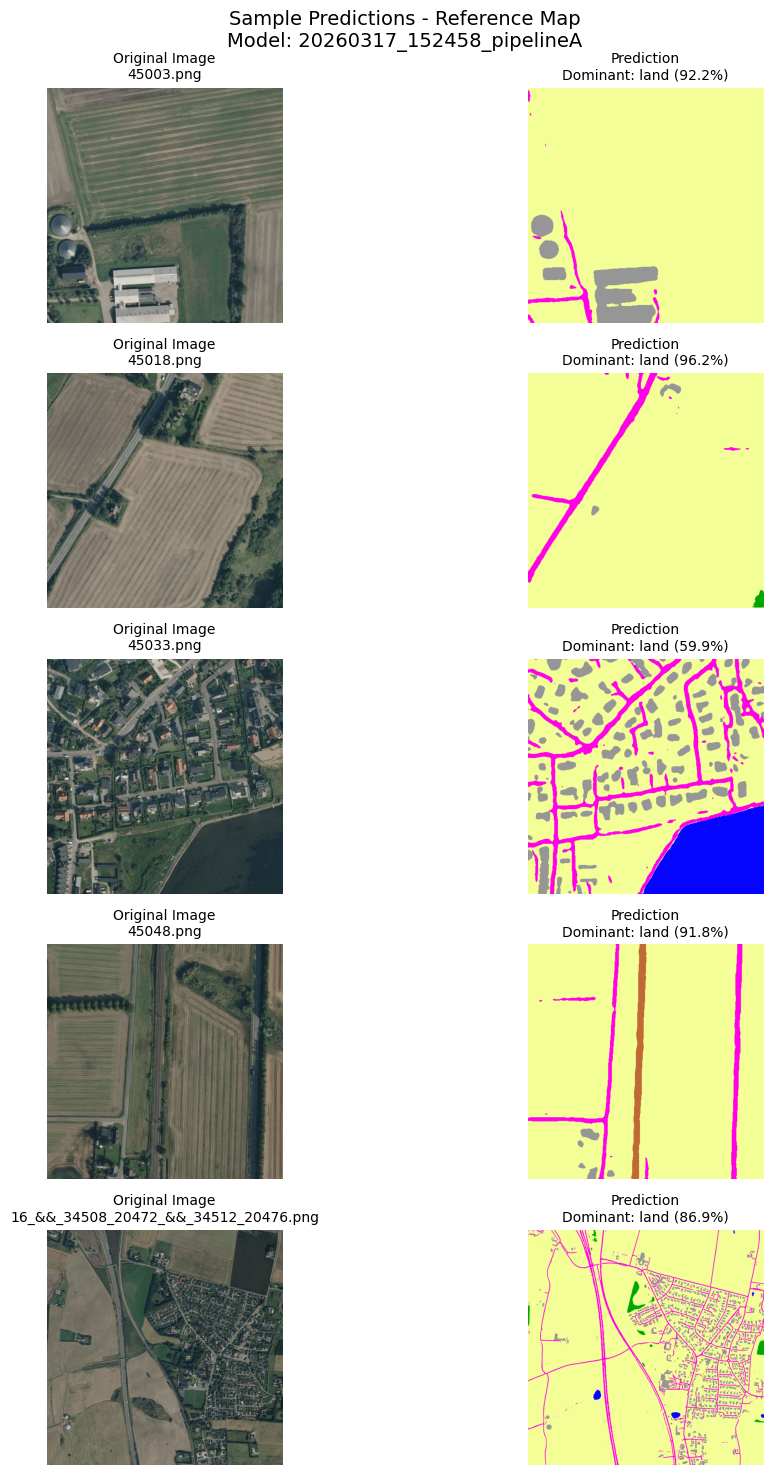

✓ Saved: REFERENCE_MAP_VEJLE_20260321_162024\sample_predictions.png


In [15]:
# Visualization 2: Sample predictions
print("Generating sample predictions visualization...")

# Select diverse samples (first, quartiles, last)
sample_indices = [
    0, 
    len(predictions) // 4, 
    len(predictions) // 2, 
    3 * len(predictions) // 4, 
    len(predictions) - 1
]
sample_indices = [i for i in sample_indices if i < len(predictions)]

fig, axes = plt.subplots(len(sample_indices), 2, figsize=(12, len(sample_indices) * 3))
if len(sample_indices) == 1:
    axes = axes.reshape(1, -1)

for plot_idx, sample_idx in enumerate(sample_indices):
    # Load original image
    img_path = processed_images[sample_idx]
    img = np.array(Image.open(img_path).convert('RGB'))
    pred = predictions[sample_idx]
    
    # Original image
    axes[plot_idx, 0].imshow(img)
    axes[plot_idx, 0].axis('off')
    axes[plot_idx, 0].set_title(f'Original Image\n{Path(img_path).name}', fontsize=10)
    
    # Prediction
    axes[plot_idx, 1].imshow(decode_segmap(pred, COLOR_MAP))
    axes[plot_idx, 1].axis('off')
    
    # Add class distribution for this image
    unique, counts = np.unique(pred, return_counts=True)
    top_class = unique[np.argmax(counts)]
    top_pct = 100 * np.max(counts) / pred.size
    axes[plot_idx, 1].set_title(f'Prediction\nDominant: {CLASS_NAMES[top_class]} ({top_pct:.1f}%)', fontsize=10)

plt.suptitle(f'Sample Predictions - Reference Map\nModel: {RUN_NAME}', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUT_DIR / 'sample_predictions.png'}")

In [16]:
# Save results to JSON
results = {
    'model': {
        'run_name': RUN_NAME,
        'checkpoint': CHECKPOINT,
        'num_classes': NUM_CLASSES,
        'class_names': CLASS_NAMES
    },
    'dataset': {
        'reference_map_dir': str(REFERENCE_MAP_DIR),
        'total_images_in_dir': total_images,
        'sample_interval': SAMPLE_INTERVAL,
        'images_processed': len(processed_images)
    },
    'output': {
        'aerial_dir': str(OUTPUT_AERIAL_DIR),
        'prediction_dir': str(OUTPUT_PREDICTION_DIR),
        'results_dir': str(OUTPUT_DIR)
    },
    'statistics': {
        'total_pixels_analyzed': int(total_pixels),
        'avg_pixels_per_image': float(total_pixels / len(processed_images))
    },
    'class_distribution': {
        CLASS_NAMES[i]: {
            'pixel_count': int(class_pixel_counts[i]),
            'percentage': float(100 * class_pixel_counts[i] / total_pixels),
            'avg_per_image': float(class_pixel_counts[i] / len(processed_images))
        }
        for i in range(NUM_CLASSES)
    }
}

with open(OUTPUT_DIR / 'inference_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"✓ Saved: {OUTPUT_DIR / 'inference_results.json'}")

✓ Saved: REFERENCE_MAP_VEJLE_20260321_162024\inference_results.json


In [17]:
# Final summary
print("\n" + "="*70)
print("INFERENCE COMPLETE")
print("="*70)
print(f"✓ Processed:       {len(processed_images):>10,} images")
print(f"✓ Pixels analyzed: {total_pixels:>10,}")
print(f"✓ Aerial saved:    {OUTPUT_AERIAL_DIR}")
print(f"✓ Predictions saved: {OUTPUT_PREDICTION_DIR}")
print(f"✓ Results saved:   {OUTPUT_DIR}")
print("="*70)
print("\nFiles created:")
print(f"  • Aerial images:      {OUTPUT_AERIAL_DIR}/*.png ({len(processed_images):,} files)")
print(f"  • Prediction masks:   {OUTPUT_PREDICTION_DIR}/*.png ({len(processed_images):,} files)")
print(f"  • {OUTPUT_DIR / 'class_distribution.png'}")
print(f"  • {OUTPUT_DIR / 'sample_predictions.png'}")
print(f"  • {OUTPUT_DIR / 'inference_results.json'}")
print("="*70)


INFERENCE COMPLETE
✓ Processed:            4,141 images
✓ Pixels analyzed: 2,224,291,840
✓ Aerial saved:    REFERENCE_MAP_VEJLE_20260321_162024\aerial
✓ Predictions saved: REFERENCE_MAP_VEJLE_20260321_162024\prediction
✓ Results saved:   REFERENCE_MAP_VEJLE_20260321_162024

Files created:
  • Aerial images:      REFERENCE_MAP_VEJLE_20260321_162024\aerial/*.png (4,141 files)
  • Prediction masks:   REFERENCE_MAP_VEJLE_20260321_162024\prediction/*.png (4,141 files)
  • REFERENCE_MAP_VEJLE_20260321_162024\class_distribution.png
  • REFERENCE_MAP_VEJLE_20260321_162024\sample_predictions.png
  • REFERENCE_MAP_VEJLE_20260321_162024\inference_results.json
